In [1]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

from utils.score_responses import ResponseEvaluator
from utils.parsing import parse_fen

In [2]:
# CONFIG
PARENT_DIR = Path("model_outputs")
DATA_FOLDERS = [
    'eval-qwen25-7b-sftdm6-drgrpo-dm6-400',
    'l4mav-rejsampling-predictmove-no_cutoff',
    'llmchess-kimi-k2-rejsampling-1000',
    'rejsampling-llama4-maverick-7_11_25',
    'llmchess-qwen25-7b-400'
]

In [3]:
# Populate our board result dicts
board_result_dicts = {}
for data_folder in DATA_FOLDERS:
    folder_path = Path(PARENT_DIR) / data_folder
    for json_file in folder_path.glob("*.json"):
        key = f"{json_file.name} - [{data_folder}]"
        evaluator = ResponseEvaluator(str(folder_path), json_file.name)
        board_result_dicts[key] = evaluator.board_id_results

--------------------------------------------------
Results for predictmove_eval_400_all_20250722-152307.json:
Filename: predictmove_eval_400_all_20250722-152307.json
Count: Sample Questions: 400
Count: Total Generations: 400
Count: Legal Generations: 277
Total: Cumulative Score: 155.771418142284
Error: Illegal Move: 119
Error: Parsing: 4
Error: Other: 0
Avg. Score - All: 0.38942854535571003
Avg. Score - Legal: 0.5623516900443466
Error Rate: 0.3075
--------------------------------------------------

--------------------------------------------------
Results for predictmove_rejsampling_10000_correct_20250714-204608.json:
Filename: predictmove_rejsampling_10000_correct_20250714-204608.json
Count: Sample Questions: 4259
Count: Total Generations: 4259
Count: Legal Generations: 4259
Total: Cumulative Score: 2380.8955850374846
Error: Illegal Move: 0
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 0.5590269042116658
Avg. Score - Legal: 0.5590269042116658
Error Rate: 0.0
-------------------

In [4]:
def bar_by(df, x_col, y_col, *, n_bins=10, title=None):
    """
    Dual‑axis bar plot:
      • left  y‑axis: mean(y_col) per bucket (blue)
      • right y‑axis: count per bucket (orange)

    Buckets: unique values if ≤10 else `n_bins` equal‑width numeric buckets.
    """
    x, y = df[x_col], df[y_col]

    # ── Bucket assignment ────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(x):
        if x.nunique() <= 10:
            labels = sorted(x.unique())
            grp_idx = x
        else:
            bins   = np.linspace(x.min(), x.max(), n_bins + 1)
            labels = [f"{int(bins[i])}–{int(bins[i+1]-1)}" for i in range(n_bins)]
            grp_idx = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:  # categorical x
        labels  = sorted(x.astype(str).unique())
        grp_idx = x.astype(str)

    # ── Aggregation ──────────────────────────────────────────────────
    mean_vals  = y.groupby(grp_idx, observed=True).mean().reindex(labels)
    count_vals = y.groupby(grp_idx, observed=True).count().reindex(labels).fillna(0)

    # ── Plot ─────────────────────────────────────────────────────────
    xpos, width = np.arange(len(labels)), 0.35
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    bars_mean  = ax1.bar(xpos - width/2, mean_vals.values, width, color="#1f77b4")
    bars_count = ax2.bar(xpos + width/2, count_vals.values, width,
                         color="orange", label="# samples")

    ax1.set_xlabel(x_col)
    ax1.set_ylabel(f"mean({y_col})")
    ax2.set_ylabel("count")
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")
    ax1.set_title(title or f"{y_col} by {x_col}")

    # Annotate bars
    for rect in bars_mean:
        ax1.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{rect.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
    for rect in bars_count:
        ax2.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{int(rect.get_height())}",
                 ha="center", va="bottom", fontsize=8)

    ax1.legend([bars_count], ["# samples"], loc="upper right")
    fig.tight_layout()
    plt.show()

# Predict Move   
---

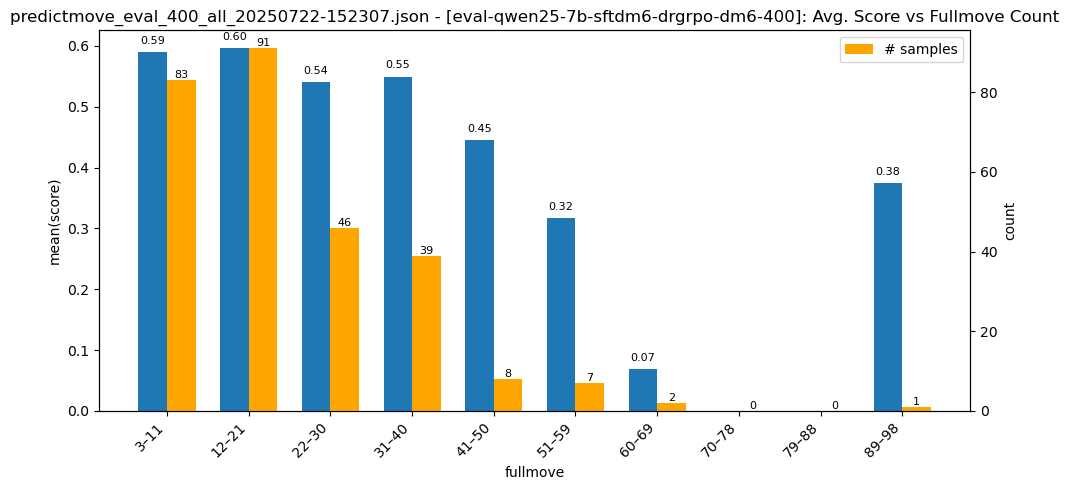


predictmove_eval_400_all_20250722-152307.json - [eval-qwen25-7b-sftdm6-drgrpo-dm6-400] — Top 20 moves:
a8b8     count=100   mean=0.569 std=0.210
a1b1     count=50    mean=0.550 std=0.189
f1e1     count=50    mean=0.644 std=0.285
b8a8     count=15    mean=0.628 std=0.204
f8e8     count=15    mean=0.589 std=0.231
b1d2     count=11    mean=0.784 std=0.194
c1b1     count=9     mean=0.477 std=0.276
b8d7     count=9     mean=0.773 std=0.233
d1c1     count=8     mean=0.246 std=0.128
d8c8     count=8     mean=0.558 std=0.183
e1d1     count=7     mean=0.833 std=0.113
e8d8     count=6     mean=0.609 std=0.196
b1a1     count=4     mean=0.483 std=0.089
h1g1     count=4     mean=0.407 std=0.174
e2d2     count=4     mean=0.455 std=0.313
<ERROR>  count=4     mean=— std=—
c2b1     count=4     mean=0.443 std=0.407
f2e2     count=4     mean=0.558 std=0.417
b2a2     count=3     mean=0.720 std=0.196
g8f8     count=3     mean=— std=—
------------------------------------------------------------


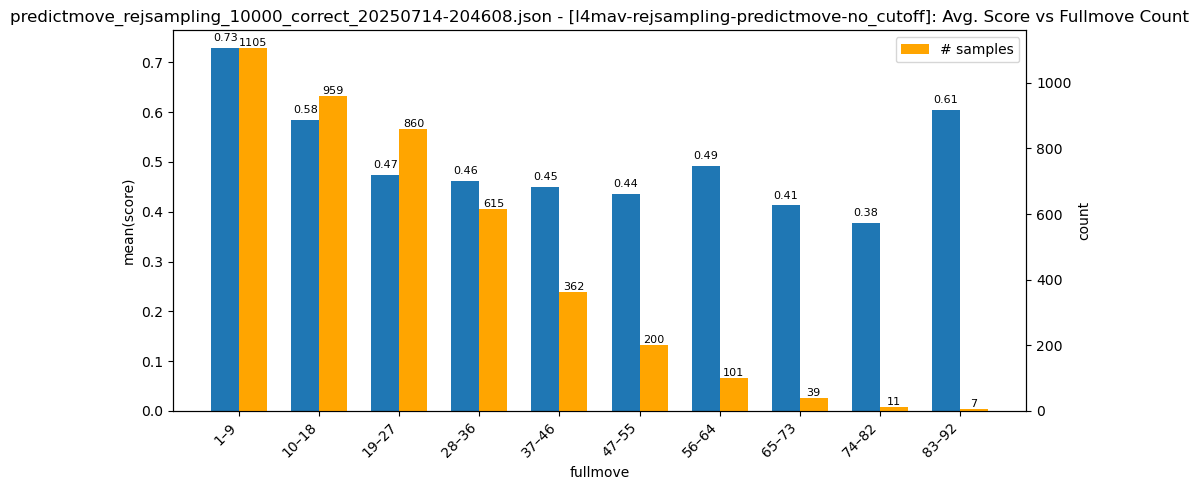


predictmove_rejsampling_10000_correct_20250714-204608.json - [l4mav-rejsampling-predictmove-no_cutoff] — Top 20 moves:
e1g1     count=176   mean=0.773 std=0.214
g1f3     count=160   mean=0.833 std=0.179
b1c3     count=158   mean=0.768 std=0.223
g8f6     count=153   mean=0.709 std=0.296
b8c6     count=142   mean=0.765 std=0.244
d7d5     count=137   mean=0.698 std=0.290
e8g8     count=100   mean=0.793 std=0.228
c7c5     count=73    mean=0.514 std=0.286
d2d4     count=60    mean=0.797 std=0.209
d1e2     count=56    mean=0.684 std=0.252
e7e5     count=48    mean=0.511 std=0.341
f7f5     count=47    mean=0.534 std=0.309
b2b3     count=42    mean=0.544 std=0.239
f1e1     count=39    mean=0.574 std=0.248
d1d3     count=38    mean=0.442 std=0.356
d8d5     count=29    mean=0.456 std=0.359
a1d1     count=28    mean=0.630 std=0.295
g7g6     count=27    mean=0.478 std=0.277
c3d5     count=24    mean=0.493 std=0.327
d1c2     count=24    mean=0.570 std=0.334
----------------------------------------

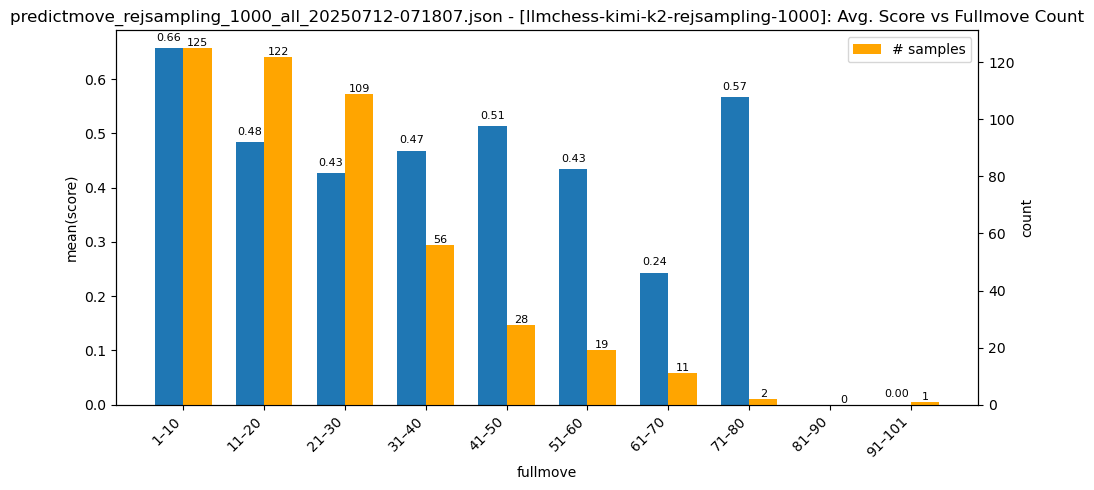


predictmove_rejsampling_1000_all_20250712-071807.json - [llmchess-kimi-k2-rejsampling-1000] — Top 20 moves:
e1g1     count=48    mean=0.891 std=0.079
e8g8     count=44    mean=0.763 std=0.246
g8f6     count=16    mean=0.826 std=0.248
d7d5     count=12    mean=0.683 std=0.280
c3e4     count=10    mean=0.283 std=0.307
f6e4     count=10    mean=0.338 std=0.259
g1f3     count=10    mean=0.884 std=0.086
b8c6     count=9     mean=0.838 std=0.172
h7h6     count=8     mean=0.788 std=0.198
e5e6     count=8     mean=0.449 std=0.308
d6d5     count=8     mean=0.422 std=0.304
f3e5     count=7     mean=0.219 std=0.131
f7f6     count=7     mean=0.649 std=0.195
b1c3     count=7     mean=0.551 std=0.286
c3d5     count=6     mean=0.509 std=0.380
e7e5     count=6     mean=0.662 std=0.362
d4d5     count=5     mean=0.530 std=0.616
g5f6     count=5     mean=0.365 std=0.324
e8c8     count=5     mean=0.619 std=0.182
d7d6     count=5     mean=0.821 std=—
-------------------------------------------------------

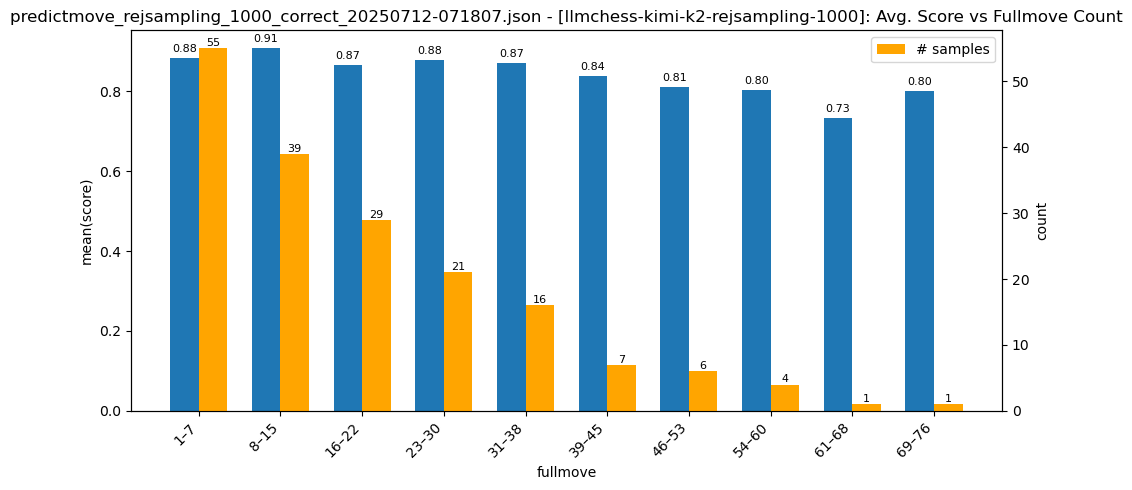


predictmove_rejsampling_1000_correct_20250712-071807.json - [llmchess-kimi-k2-rejsampling-1000] — Top 20 moves:
e1g1     count=19    mean=0.891 std=0.079
e8g8     count=16    mean=0.889 std=0.077
g8f6     count=9     mean=0.902 std=0.068
g1f3     count=7     mean=0.884 std=0.086
b8c6     count=6     mean=0.898 std=0.075
e7e5     count=4     mean=0.819 std=0.103
d2e4     count=4     mean=0.888 std=0.062
h7h6     count=4     mean=0.933 std=0.075
d7d5     count=4     mean=0.868 std=0.087
b1c3     count=3     mean=0.771 std=0.072
c4d5     count=2     mean=0.830 std=0.159
a1d1     count=2     mean=0.945 std=0.011
a2a3     count=2     mean=0.969 std=0.003
c3d5     count=2     mean=0.899 std=0.010
f4g3     count=2     mean=0.812 std=0.088
e6d5     count=2     mean=0.921 std=0.077
c4b4     count=2     mean=0.859 std=0.070
d1c2     count=1     mean=0.788 std=—
d2d4     count=1     mean=0.923 std=—
g3h5     count=1     mean=0.795 std=—
-----------------------------------------------------------

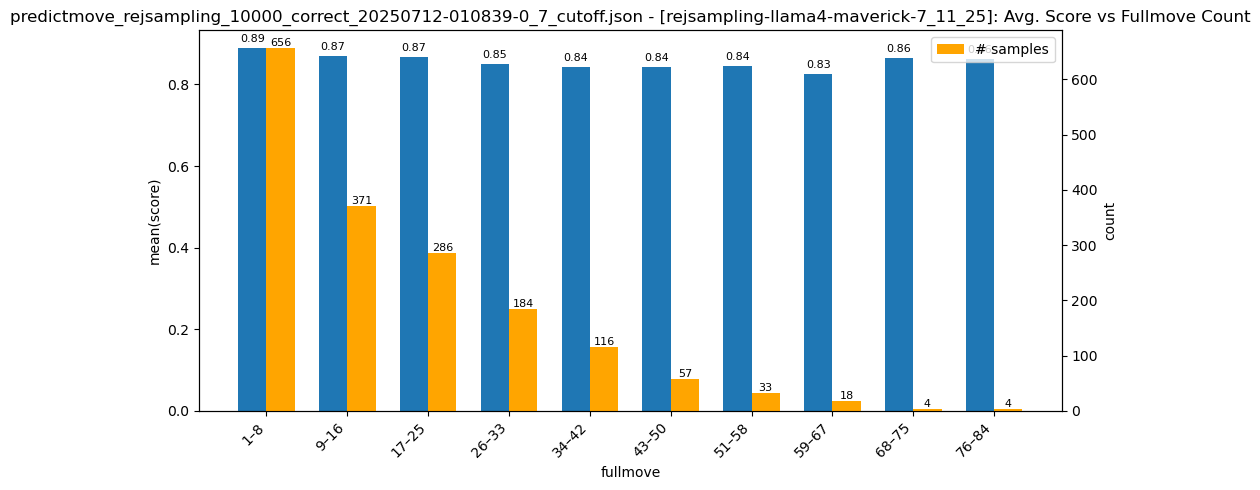


predictmove_rejsampling_10000_correct_20250712-010839-0_7_cutoff.json - [rejsampling-llama4-maverick-7_11_25] — Top 20 moves:
g1f3     count=123   mean=0.903 std=0.060
b8c6     count=122   mean=0.888 std=0.072
e1g1     count=116   mean=0.875 std=0.084
b1c3     count=105   mean=0.874 std=0.085
g8f6     count=96    mean=0.884 std=0.072
d7d5     count=85    mean=0.882 std=0.081
e8g8     count=72    mean=0.913 std=0.064
d2d4     count=56    mean=0.912 std=0.061
d1e2     count=30    mean=0.843 std=0.076
c7c5     count=25    mean=0.864 std=0.088
a1d1     count=14    mean=0.859 std=0.073
e7e5     count=14    mean=0.877 std=0.090
h7h6     count=13    mean=0.907 std=0.072
f1e1     count=13    mean=0.864 std=0.075
d2f3     count=13    mean=0.860 std=0.099
d8e7     count=13    mean=0.847 std=0.086
c1b1     count=11    mean=0.851 std=0.082
f7f5     count=11    mean=0.814 std=0.087
g7g6     count=10    mean=0.885 std=0.068
f1d1     count=10    mean=0.850 std=0.063
---------------------------------

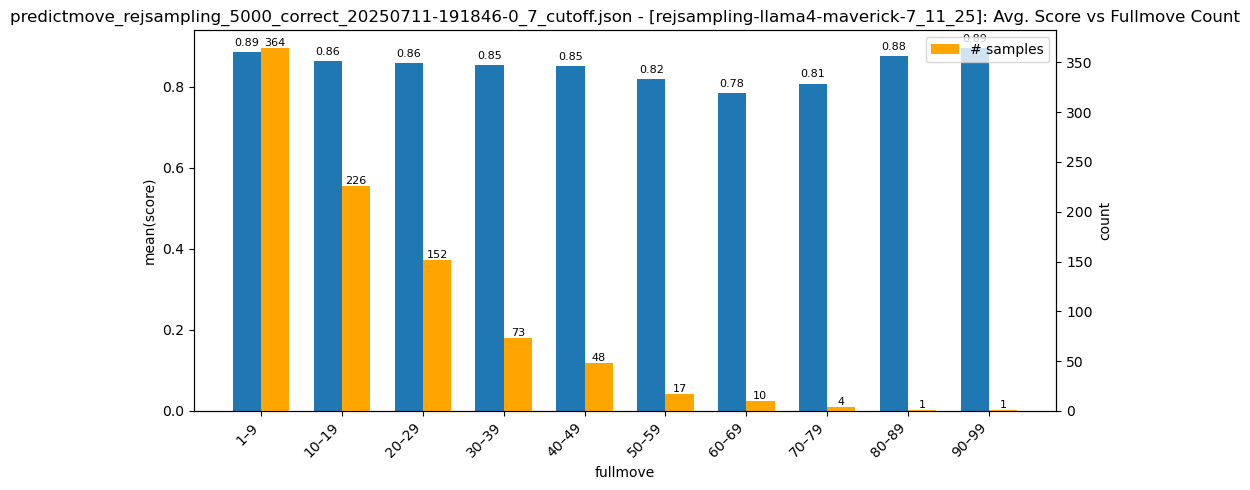


predictmove_rejsampling_5000_correct_20250711-191846-0_7_cutoff.json - [rejsampling-llama4-maverick-7_11_25] — Top 20 moves:
g1f3     count=76    mean=0.902 std=0.068
e1g1     count=74    mean=0.876 std=0.082
b8c6     count=57    mean=0.865 std=0.085
b1c3     count=51    mean=0.857 std=0.077
g8f6     count=43    mean=0.909 std=0.065
e8g8     count=40    mean=0.899 std=0.084
d7d5     count=38    mean=0.904 std=0.072
d2d4     count=24    mean=0.915 std=0.060
c7c5     count=13    mean=0.855 std=0.091
a1d1     count=10    mean=0.859 std=0.084
f7f5     count=8     mean=0.872 std=0.079
d1e2     count=8     mean=0.825 std=0.082
d2f3     count=7     mean=0.842 std=0.071
e7e5     count=7     mean=0.863 std=0.077
f1e1     count=7     mean=0.890 std=0.076
c3d5     count=7     mean=0.891 std=0.067
d1d3     count=7     mean=0.872 std=0.081
e2e4     count=6     mean=0.864 std=0.067
g7g6     count=6     mean=0.827 std=0.054
c1b1     count=6     mean=0.867 std=0.043
----------------------------------

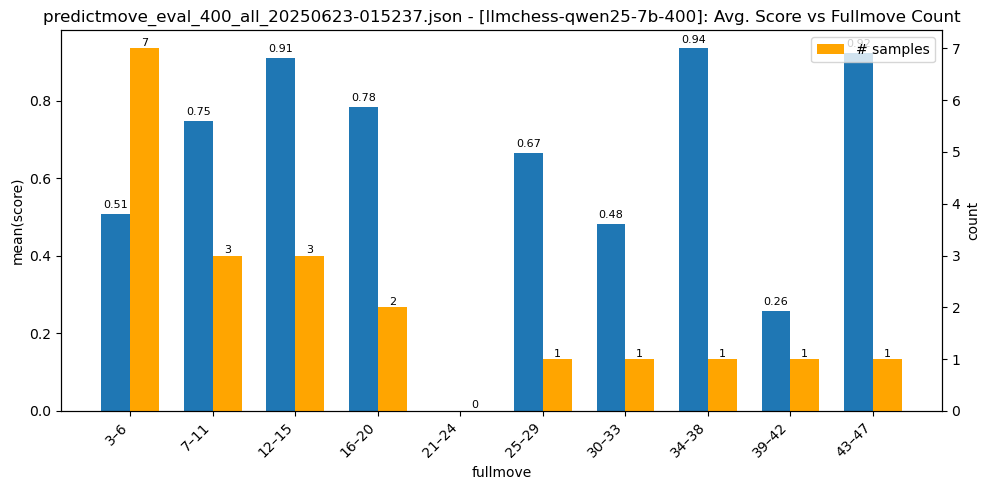


predictmove_eval_400_all_20250623-015237.json - [llmchess-qwen25-7b-400] — Top 20 moves:
e2e4     count=14    mean=— std=—
d2d4     count=11    mean=— std=—
e5       count=8     mean=— std=—
e7e5     count=8     mean=0.120 std=—
g1f3     count=8     mean=0.800 std=—
g8f6     count=6     mean=0.118 std=—
g7g5     count=6     mean=0.635 std=0.101
d4d5     count=6     mean=— std=—
f7f5     count=5     mean=0.837 std=—
Qf6      count=5     mean=— std=—
d7d5     count=5     mean=— std=—
c2c4     count=5     mean=0.971 std=—
c6d4     count=4     mean=0.791 std=—
d4       count=4     mean=— std=—
Ng8f6    count=4     mean=— std=—
e1g1     count=4     mean=0.957 std=0.017
Ng4      count=4     mean=— std=—
b7b5     count=4     mean=0.321 std=—
d5       count=4     mean=— std=—
f2f4     count=4     mean=— std=—
------------------------------------------------------------


In [5]:
for key, results in board_result_dicts.items():
    if not key.startswith("predictmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fullmove = parse_fen(data['info']["board"])["fullmove_number"]
        for score_raw, move in data.get("score_answers", []):
            try:         # numeric score or NaN for '<ERROR>'
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "move":     move,
                "score":    score,
            })

    if not rows:
        continue

    df = pd.DataFrame(rows)

    # ── 1) Histogram (mean score vs fullmove buckets) ────────────
    clean_df = df.dropna(subset=["score"])
    if not clean_df.empty:
        bar_by(
            clean_df,
            x_col="fullmove",
            y_col="score",
            n_bins=10,
            title=f"{key}: Avg. Score vs Fullmove Count"
        )

    # ── 2) Move statistics ───────────────────────────────────────
    print(f"\n{key} — Top 20 moves:")
    move_counts = df["move"].value_counts().head(20)
    move_stats  = (
        df.groupby("move")["score"]
            .agg(["mean", "std"])
            .reindex(move_counts.index)
    )
    for mv in move_counts.index:
        cnt  = move_counts[mv]
        mean = move_stats.loc[mv, "mean"]
        std  = move_stats.loc[mv, "std"]
        mean_str = f"{mean:.3f}" if not np.isnan(mean) else "—"
        std_str  = f"{std:.3f}"  if not np.isnan(std)  else "—"
        print(f"{mv:<8} count={cnt:<5} mean={mean_str} std={std_str}")
    print("-" * 60)

# Legal Moves   
---

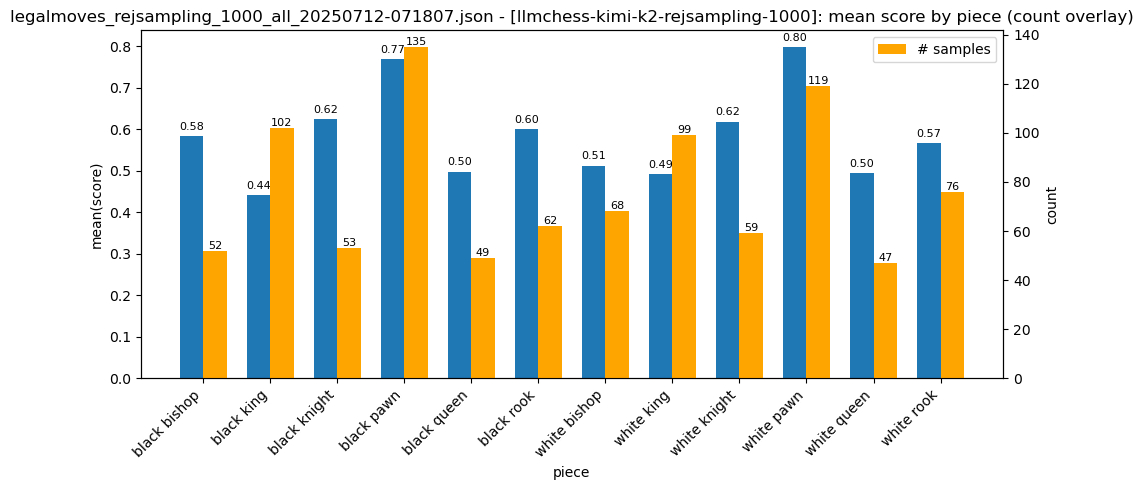

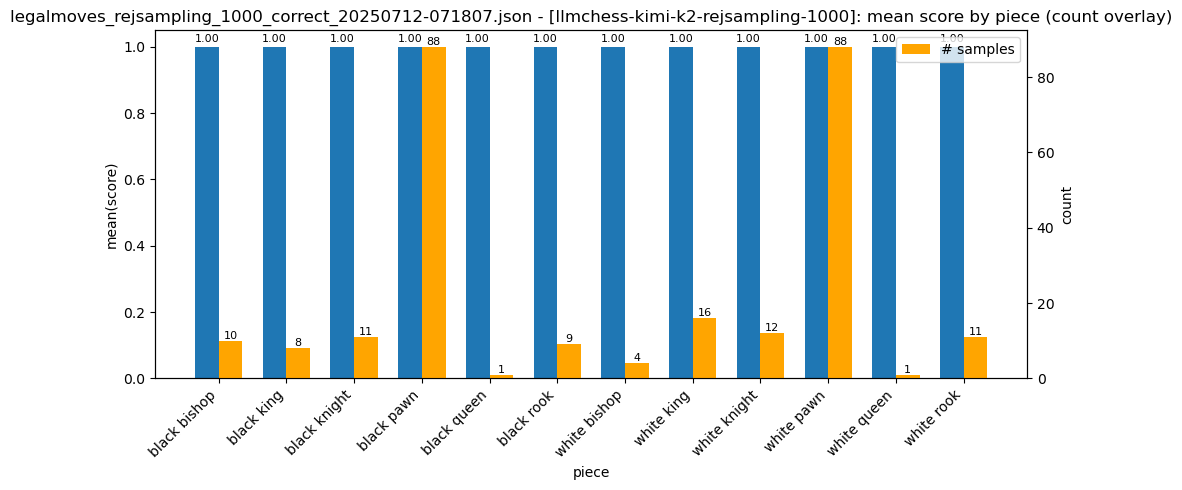

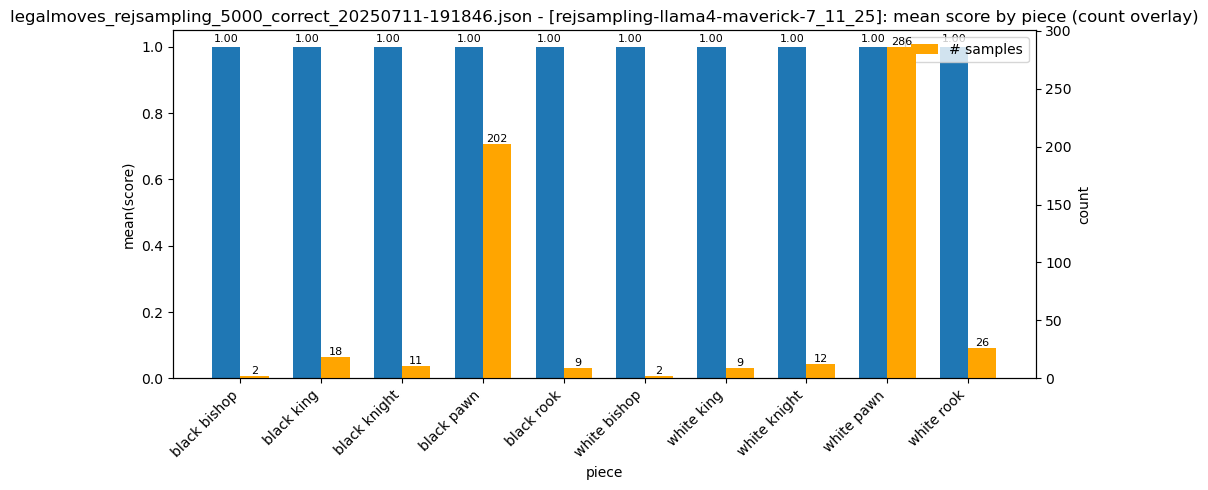

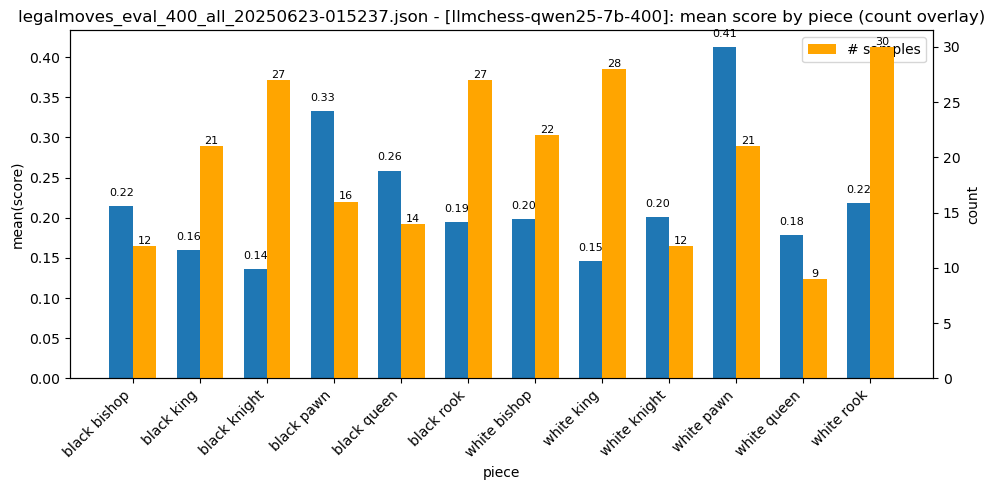

In [7]:
for key, results in board_result_dicts.items():
    if not key.startswith("legalmoves"):
        continue

    rows = []
    for board_id, data in results.items():
        piece = data["info"]["task_data"][0]   # e.g. 'black bishop'
        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)      # 0‥1 numeric
            except (ValueError, TypeError):
                score = pd.NA                 # '<ERROR>' → NA
            rows.append({"piece": piece, "score": score})

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores")
        continue

    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )